**Programmer:** python_scripts (Abhijith Warrier)

**PYTHON SCRIPT TO _OPTIMISE CLASSIFICATION DECISIONS BY TUNING THE PREDICTION THRESHOLD_. ⚡️🎯🤖**

This script demonstrates how to move beyond the default **0.5 classification threshold** and choose a threshold that better matches the real-world objective of the problem. Threshold tuning is especially useful when **false positives** and **false negatives** have different costs.

---

## **📦 Import Required Libraries**

We use scikit-learn utilities for classification, evaluation, and threshold analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

---

## **🧩 Load the Dataset**

We’ll use a binary classification dataset where threshold tuning makes sense.

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

---

## **✂️ Split Data into Train and Test Sets**

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

---

## **🤖 Train the Classification Model**

We train a model that can output prediction probabilities.

In [4]:
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


---

## **📊 Generate Predicted Probabilities**

Instead of using class predictions directly, we use probabilities for the positive class.

In [5]:
y_probs = model.predict_proba(X_test)[:, 1]

This gives us the flexibility to test different classification thresholds.

---

## **🎯 Apply the Default Threshold (0.5)**

By default, most classifiers convert probabilities to labels using 0.5.

In [6]:
y_pred_default = (y_probs >= 0.5).astype(int)

print("Default Threshold = 0.5")
print("Precision:", precision_score(y_test, y_pred_default))
print("Recall:", recall_score(y_test, y_pred_default))
print("F1 Score:", f1_score(y_test, y_pred_default))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_default))

Default Threshold = 0.5
Precision: 0.9375
Recall: 0.9813084112149533
F1 Score: 0.958904109589041
Confusion Matrix:
 [[ 57   7]
 [  2 105]]


This gives us a baseline to compare against.

---

## **🔁 Evaluate Multiple Thresholds**

We now test a range of thresholds and calculate metrics for each one.

In [7]:
thresholds = np.arange(0.1, 0.91, 0.1)

results = []

for threshold in thresholds:
    y_pred = (y_probs >= threshold).astype(int)

    results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print(results_df)

   threshold  precision    recall        f1
0        0.1   0.899160  1.000000  0.946903
1        0.2   0.930435  1.000000  0.963964
2        0.3   0.929825  0.990654  0.959276
3        0.4   0.929825  0.990654  0.959276
4        0.5   0.937500  0.981308  0.958904
5        0.6   0.945946  0.981308  0.963303
6        0.7   0.953704  0.962617  0.958140
7        0.8   0.971429  0.953271  0.962264
8        0.9   0.979167  0.878505  0.926108


This helps us see how precision, recall, and F1-score change as the threshold moves.

---

## **📈 Visualize Threshold Tuning**

We plot the metrics across thresholds to identify the best trade-off.

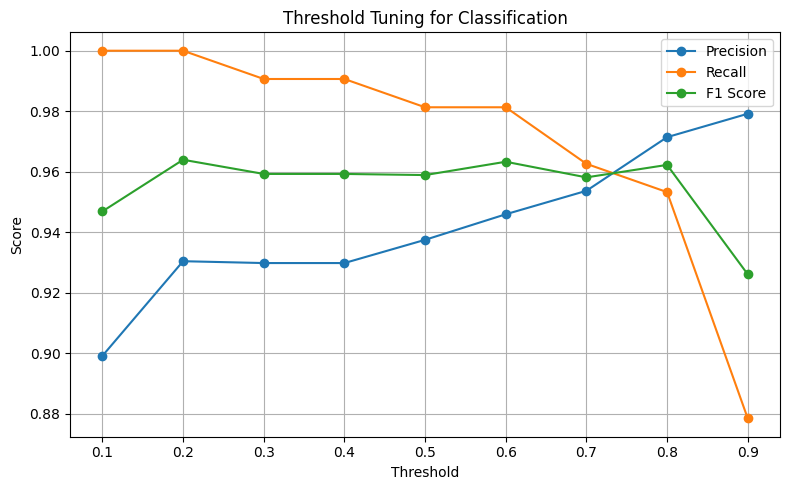

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(results_df["threshold"], results_df["precision"], marker="o", label="Precision")
plt.plot(results_df["threshold"], results_df["recall"], marker="o", label="Recall")
plt.plot(results_df["threshold"], results_df["f1"], marker="o", label="F1 Score")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning for Classification")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

This plot makes it easy to select a threshold that matches the problem’s priority.

---

## **✅ Choose a Custom Threshold**

We can now choose a threshold that balances metrics better than 0.5.

In [9]:
best_threshold = results_df.loc[results_df["f1"].idxmax(), "threshold"]
print("Best Threshold based on F1:", best_threshold)

Best Threshold based on F1: 0.2


This is just one strategy — in real systems, the best threshold depends on business cost.

---

## **🔍 Why Threshold Tuning Matters**

Threshold tuning is important because:

- the default 0.5 is not always optimal
- some problems need **high recall** (catch more positives)
- some problems need **high precision** (avoid false alarms)
- model probabilities should support decision strategy

This is especially useful in:

- fraud detection
- medical diagnosis
- spam filtering
- lead scoring

---

## **🧠 Key Takeaways**

1. Classification thresholds directly affect business outcomes.
2. The default threshold of 0.5 is not always the best choice.
3. Lower thresholds usually increase recall and reduce precision.
4. Higher thresholds usually increase precision and reduce recall.
5. Threshold tuning helps align ML systems with real-world priorities.

---

## **Conclusion**

Threshold tuning is a practical and often overlooked technique in machine learning. By adjusting the classification cutoff, we can tailor a model’s behavior to the needs of the problem rather than relying blindly on the default threshold.

This makes threshold tuning an important topic in **Saturday ML Spark ⚡️ – Advanced & Practical**.

---